# Lab 01 - Classifying Spam Emails

Notebook này được tổ chức theo từng step giống notebook mẫu: load data, EDA trước balance, preprocessing/balance, EDA sau balance, feature engineering, train model, evaluate, tune/check, và deploy.

## Step 0 — Import Libraries And Setup

In [208]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

for module_path in [NOTEBOOKS_DIR, PROJECT_ROOT]:
    module_path = str(module_path)
    if module_path in sys.path:
        sys.path.remove(module_path)
    sys.path.insert(0, module_path)

import crawl
import preprocess
import model_from_scratch
import eda

crawl = importlib.reload(crawl)
preprocess = importlib.reload(preprocess)
model_from_scratch = importlib.reload(model_from_scratch)
eda = importlib.reload(eda)
model_checker = model_from_scratch.SklearnModelChecker()

paths = crawl.project_paths(PROJECT_ROOT)
print(f"crawl module: {crawl.__file__}")
print(f"preprocess module: {preprocess.__file__}")
print(f"model module: {model_from_scratch.__file__}")
print(f"eda module: {eda.__file__}")
PROJECT_ROOT

crawl module: /Users/quangmanh/Project/lab01/notebooks/crawl.py
preprocess module: /Users/quangmanh/Project/lab01/notebooks/preprocess.py
model module: /Users/quangmanh/Project/lab01/notebooks/model_from_scratch.py
eda module: /Users/quangmanh/Project/lab01/notebooks/eda.py


PosixPath('/Users/quangmanh/Project/lab01')

## Step 1 — Raw/Processed Data: Load Dataset

Load dữ liệu raw và dữ liệu đã xử lý/balance hiện có trong project.

In [209]:
data, raw_data, paths = crawl.load_datasets(PROJECT_ROOT)
overview = crawl.dataset_overview(data, raw_data)

print(f"Processed rows: {overview['processed_rows']:,}")
print(f"Raw rows: {overview['raw_rows']:,}" if overview["raw_rows"] else "Raw dataset not found")
display(data.head(3))

Processed rows: 8,940
Raw rows: 17,967


,email_id,source,source_family,source_url,local_path,extracted_from,extracted_path,archive_path,label,sender,recipient,subject,body,text,clean_text,raw_char_count,clean_char_count,clean_word_count
0,fc8c47b9404a92ad7fc0bd6af24c2fbe9f9b4917ebb53c...,huggingface_enron_spam,huggingface_enron_spam,SetFit/enron_spam,SetFit/enron_spam,huggingface,train/162,train/162,spam,,,,"office xp - $ 60 andrea bloats full side , the...","office xp - $ 60 andrea bloats full side , th...",office xp andrea bloats suggest close base wee...,555,343,58
1,dbd54748a9b5a4790c80bd092f489212897a133512ea79...,kaggle_email_spam_classification,kaggle_email_spam_classification,/Users/quangmanh/.cache/kagglehub/datasets/pur...,/Users/quangmanh/.cache/kagglehub/datasets/pur...,/Users/quangmanh/.cache/kagglehub/datasets/pur...,combined_data.csv/207,combined_data.csv/207,ham,,,,continuing our salute to the ets employees nom...,continuing our salute to the ets employees no...,continuing salute ets employees nominated chai...,1644,1119,139
2,a40fe861dfc4e8b8b1dc69af54795b81eade3bd887825e...,freebsd_ports_2025,freebsd_ports_2025,https://mail-archive.freebsd.org/cgi/getmsg.cg...,,,,https://mail-archive.freebsd.org/cgi/getmsg.cg...,ham,Mark Millard <marklmi@yahoo.com>,bob prohaska <fbsd@www.zefox.net>,Re: Using ports across major version changes,"On Dec 17, 2025, at 12:35, bob prohaska <fbsd@...",Re: Using ports across major version changes O...,using ports major changes dec bob prohaska wro...,8420,4511,607


In [210]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8940 entries, 0 to 8939
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   email_id          8940 non-null   object
 1   source            8940 non-null   object
 2   source_family     8940 non-null   object
 3   source_url        8940 non-null   object
 4   local_path        8940 non-null   object
 5   extracted_from    8940 non-null   object
 6   extracted_path    8940 non-null   object
 7   archive_path      8940 non-null   object
 8   label             8940 non-null   object
 9   sender            8940 non-null   object
 10  recipient         8940 non-null   object
 11  subject           8940 non-null   object
 12  body              8940 non-null   object
 13  text              8940 non-null   object
 14  clean_text        8940 non-null   object
 15  raw_char_count    8940 non-null   int64 
 16  clean_char_count  8940 non-null   int64 
 17  clean_word_cou

### Step 1.1 — Missing Data Check

Đếm số giá trị missing theo từng cột của raw dataset và visualize để kiểm tra chất lượng dữ liệu trước preprocessing.

,column,missing_count,missing_percent,dtype
0,archive_path,0,0.0,object
1,body,0,0.0,object
2,email_id,0,0.0,object
3,extracted_from,0,0.0,object
4,extracted_path,0,0.0,object
5,label,0,0.0,object
6,local_path,0,0.0,object
7,recipient,0,0.0,object
8,sender,0,0.0,object
9,source,0,0.0,object


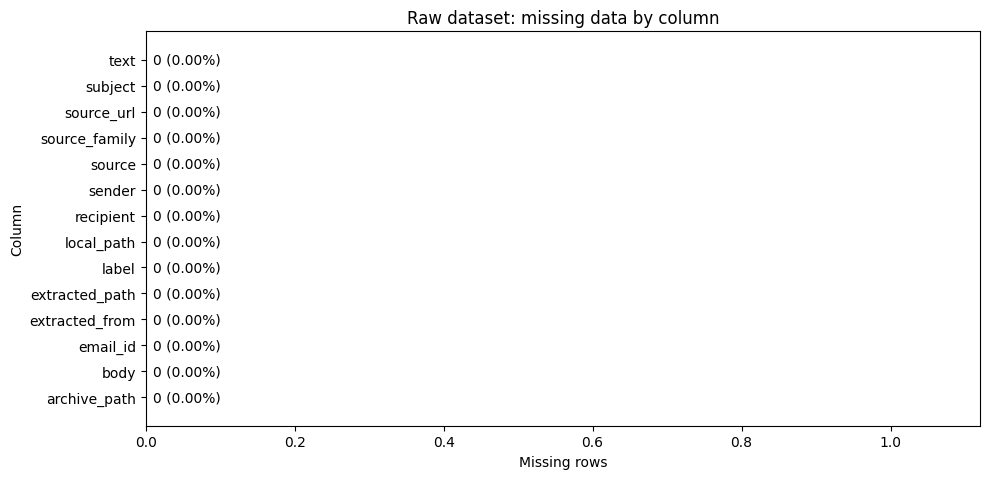

In [211]:
missing_summary = preprocess.missing_data_summary(raw_data)
display(missing_summary)
preprocess.plot_missing_data(raw_data, title="Raw dataset: missing data by column")

### Step 1.2 — Duplicate Rows Check

Đếm số dòng duplicate trong raw dataset và visualize tỉ lệ unique/duplicate trước preprocessing.

,subset,total_rows,unique_rows,duplicate_rows,duplicate_percent
0,all columns,17967,17967,0,0.0


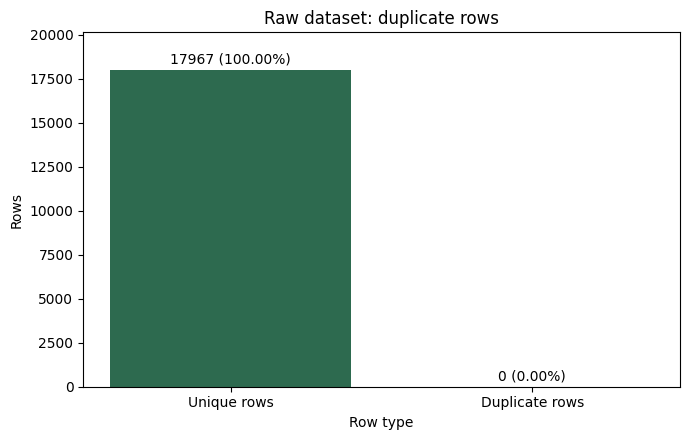

In [212]:
duplicate_summary = preprocess.duplicate_data_summary(raw_data)
display(duplicate_summary)
preprocess.plot_duplicate_data(raw_data, title="Raw dataset: duplicate rows")

### Step 1.3 — Label And Source Distribution

In [213]:
display(crawl.label_counts(data))
display(crawl.source_counts(data, top_n=15))

,label,rows
0,spam,4470
1,ham,4470


,source_family,rows
0,kaggle_email_spam_classification,795
1,aueb_enron3_spam_ham,743
2,aueb_enron2_spam_ham,737
3,spamassassin,716
4,aueb_enron1_spam_ham,705
5,huggingface_kimdongh_spam_dataset,694
6,aueb_enron4_spam_ham,693
7,aueb_enron6_spam_ham,672
8,huggingface_enron_spam,652
9,aueb_enron5_spam_ham,549


## Step 2 — Data Processing: Clean Text

Minh hoạ cách email được làm sạch trước khi đưa vào mô hình.

In [214]:
display(preprocess.processed_sample(data, rows=3, random_state=42))

,label,source_family,subject,body,clean_text
7135,ham,freebsd_current_2025,Re: Git and buildworld running at the same time,"On Sun, Sep 14, 2025 at 09:25:33AM -0700, bob ...",git buildworld running time sun sep 33am bob p...
3309,spam,spamassassin,HELP WANTED. WORK FROM HOME REPS.,Help wanted. We are a 14 year old fortune 500...,help wanted work home reps help wanted year ol...
2199,spam,aueb_enron2_spam_ham,it ' s mariah from dating service,"i ' m mariah , the girl next door .\r\nim sear...",mariah dating service mariah girl door im sear...


In [215]:
raw_example, clean_example = preprocess.example_cleaning()

print("Raw example:")
print(raw_example)
print("\nCleaned example using notebooks/preprocess.py:")
print(clean_example)

Raw example:
<html><body><h1>WIN MONEY NOW!!!</h1>
Click https://example.com/prize and email winner@example.com to claim $5,000 today.
</body></html>

Cleaned example using notebooks/preprocess.py:
win money claim today


## Step 3 — Raw-To-Clean Check On Real Rows

Cell này chứng minh preprocessing chạy trên dữ liệu raw thật, không chỉ trên ví dụ tự tạo.

In [216]:
raw_to_clean = preprocess.raw_to_clean_sample(raw_data, rows=5)
if raw_to_clean.empty:
    print("Raw dataset is not available, so this check is skipped.")
else:
    display(raw_to_clean)

,label,source_family,text,clean_text,raw_char_count,clean_char_count,clean_word_count
0,ham,spamassassin,RE: The Curse of India's Socialism > From: for...,curse india's socialism behalf james rogers cu...,1601,846,114
1,ham,spamassassin,"Re: ARRRGHHH Had GPG working, now it doesnt. H...",arrrghhh gpg working doesnt hi sun sep mdt reg...,987,460,69
2,ham,spamassassin,Re: bad focus/click behaviours On Fri Sep 13 2...,bad focus behaviours fri sep robert elz wrote ...,1527,674,102
3,ham,spamassassin,"Re: ALSA (almost) made easy On Thu, 2002-08-29...",alsa easy thu matthias saou wrote thanks lot r...,1442,699,108
4,ham,spamassassin,creating rpms with subdirs (install command) H...,creating rpms subdirs install command hi i'm b...,803,365,53


## Step 4 — EDA Before Balance

Tạo bản dữ liệu đã clean và đủ điều kiện train nhưng **chưa balance**. Step này dùng để so sánh phân phối nhãn/source trước khi cân bằng dữ liệu.

In [217]:
full_clean_data, before_balance_data, balanced_preview = preprocess.process_raw_dataset(raw_data, balance=True)

print(f"Full cleaned rows: {len(full_clean_data):,}")
print(f"Trainable rows before balance: {len(before_balance_data):,}")
print(f"Balanced preview rows: {len(balanced_preview):,}")
display(crawl.label_counts(before_balance_data))
display(eda.source_label_table(before_balance_data).head(20))
display(eda.length_summary(before_balance_data))

Full cleaned rows: 17,582
Trainable rows before balance: 17,275
Balanced preview rows: 8,940


,label,rows
0,ham,12805
1,spam,4470


label,source_family,ham,spam,total,spam_rate
17,spamassassin,770,468,1238,0.3780
15,lkml_2022_10_week_1,1000,0,1000,0.0000
16,lkml_2024_02_week_3,999,0,999,0.0000
7,freebsd_hackers_2025,992,0,992,0.0000
9,freebsd_questions_2025,987,0,987,0.0000
2,aueb_enron3_spam_ham,493,494,987,0.5005
14,kaggle_enron_email_dataset,986,0,986,0.0000
13,kaggle_email_spam_classification,437,547,984,0.5559
10,freebsd_stable_2025,983,0,983,0.0000
1,aueb_enron2_spam_ham,490,488,978,0.4990


,analysis_char_count,analysis_word_count,subject_chars
count,17275.000000,17275.000000,17275.000000
mean,1620.268133,235.970130,39.359595
std,8552.798337,1326.602752,34.723585
min,25.000000,5.000000,0.000000
25%,321.000000,45.000000,12.000000
50%,643.000000,90.000000,34.000000
75%,1435.000000,203.000000,57.000000
95%,4177.300000,601.000000,104.000000
max,393795.000000,51231.000000,452.000000


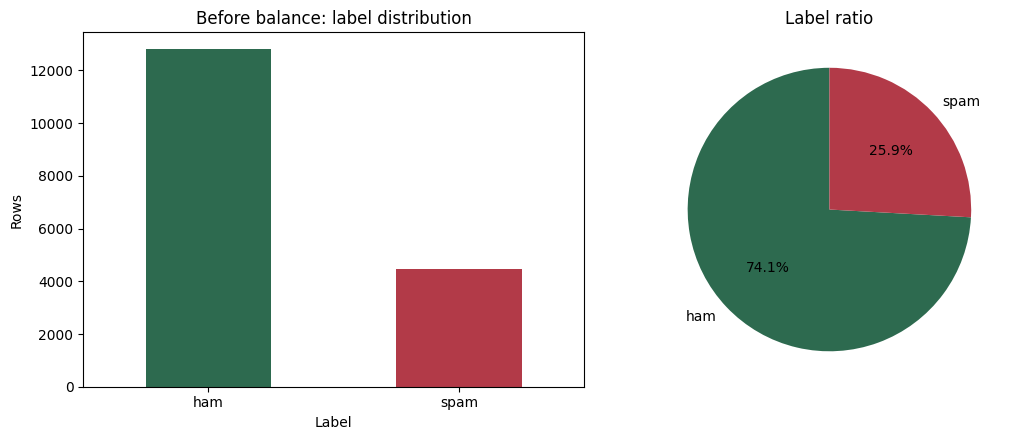

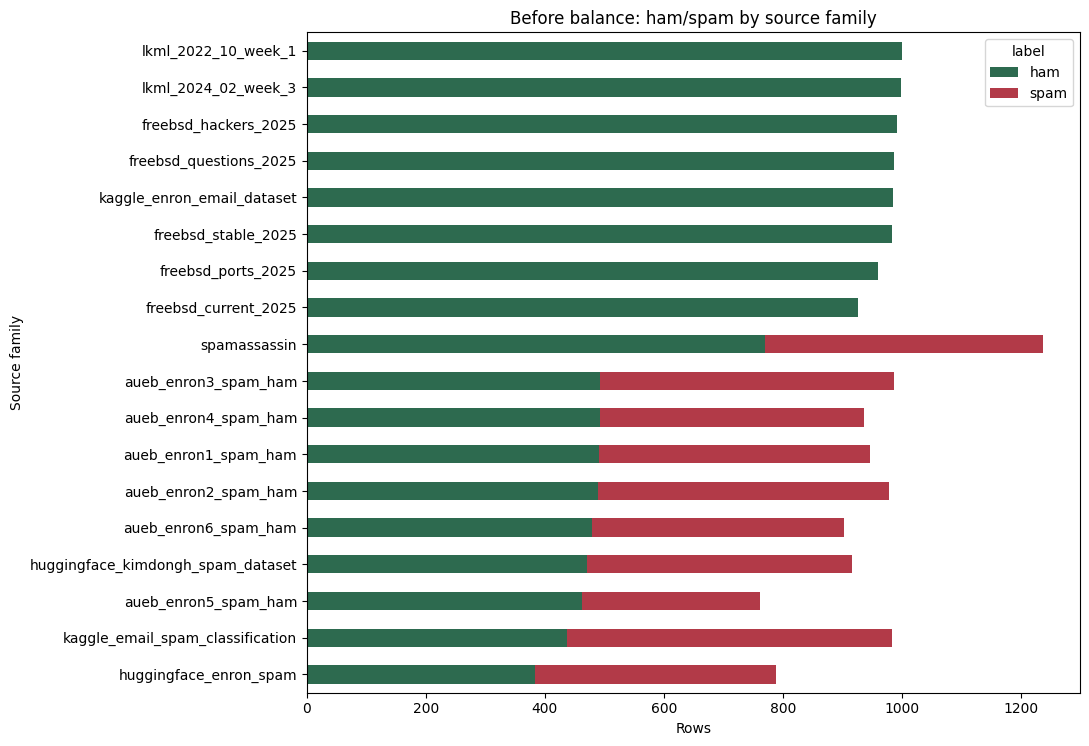

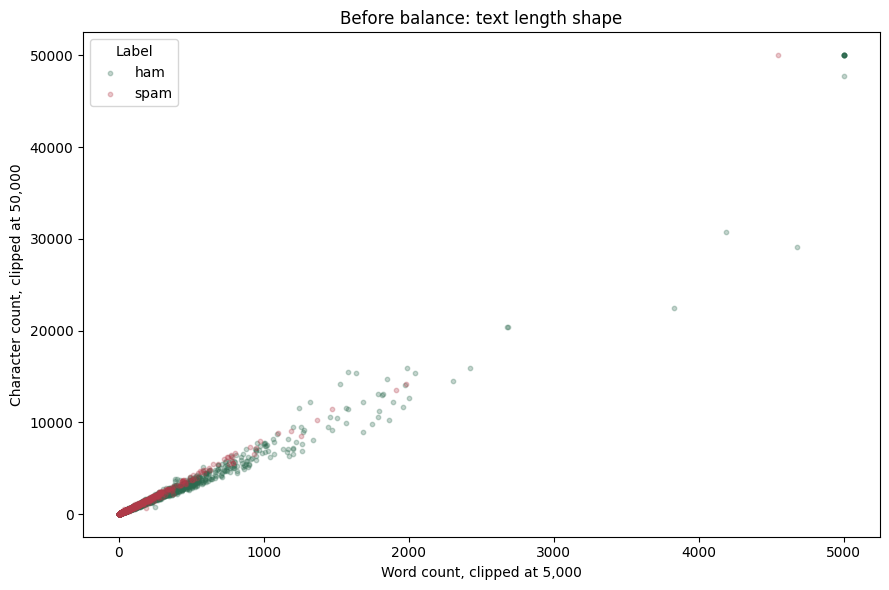

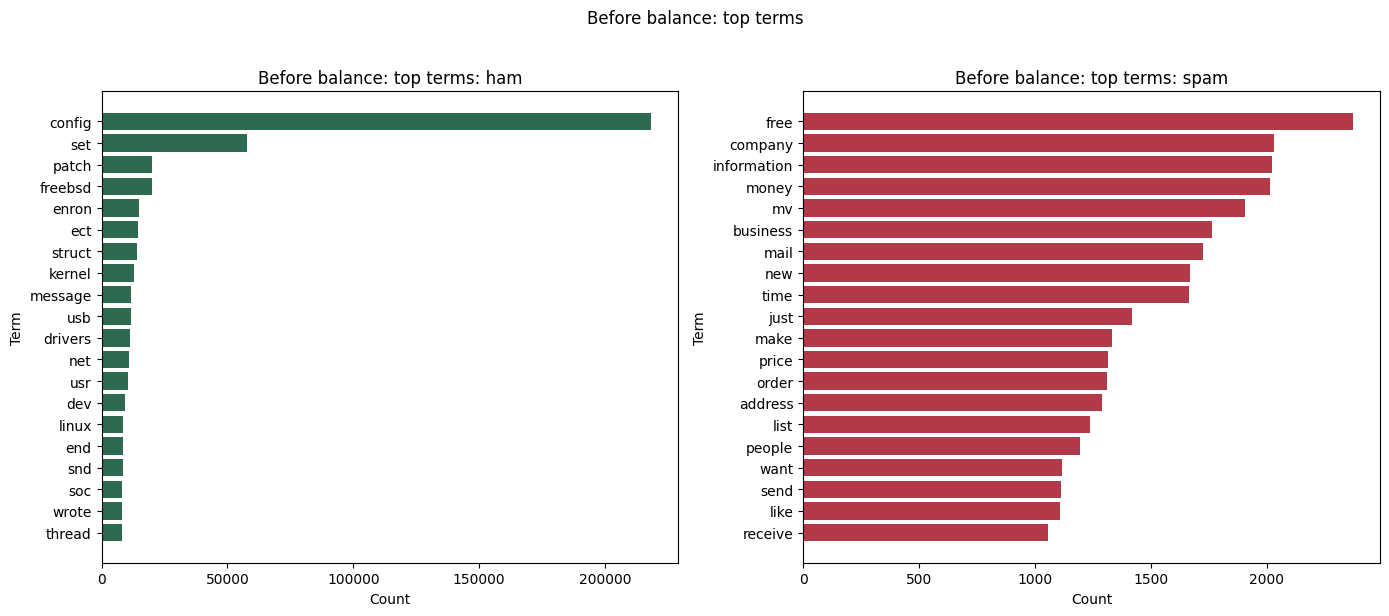

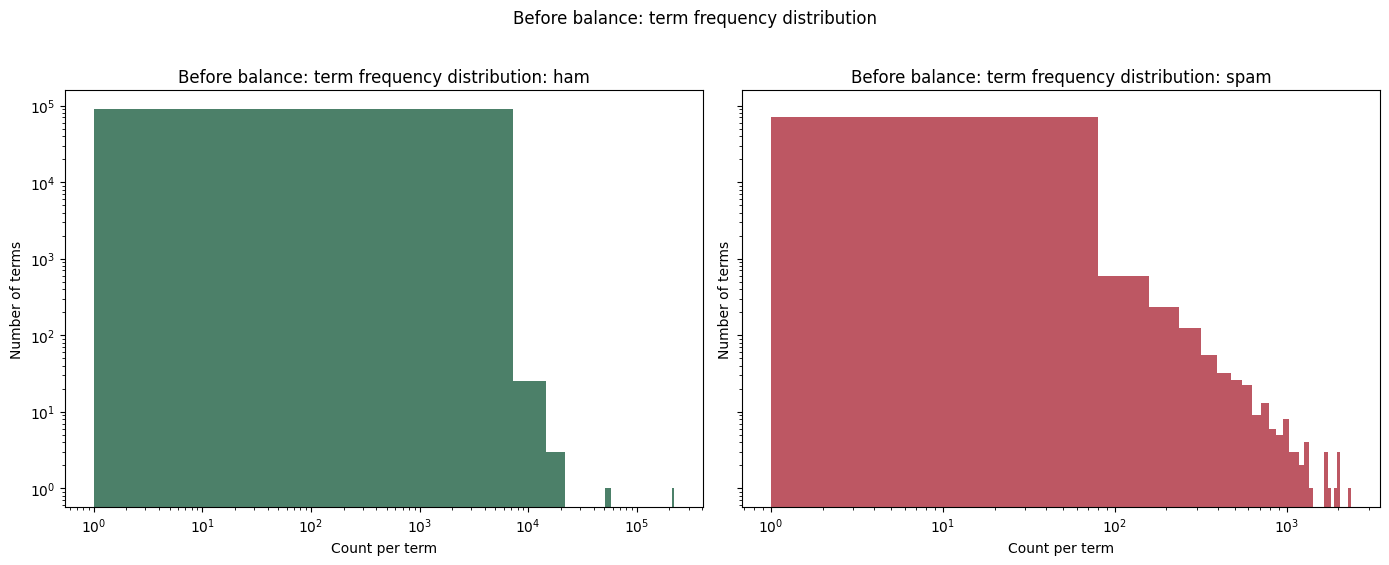

In [218]:
eda = importlib.reload(eda)
eda.plot_eda_overview(before_balance_data, title_prefix="Before balance")

## Step 5 — EDA After Balance

Đây là EDA trên dataset cuối cùng dùng để train/test. Các biểu đồ được vẽ trực tiếp trong notebook.

In [219]:
display(eda.source_label_table(data).head(20))
display(eda.length_summary(data))

label,source_family,ham,spam,total,spam_rate
13,kaggle_email_spam_classification,248,547,795,0.6881
2,aueb_enron3_spam_ham,249,494,743,0.6649
1,aueb_enron2_spam_ham,249,488,737,0.6621
17,spamassassin,248,468,716,0.6536
0,aueb_enron1_spam_ham,249,456,705,0.6468
12,huggingface_kimdongh_spam_dataset,248,446,694,0.6427
3,aueb_enron4_spam_ham,249,444,693,0.6407
5,aueb_enron6_spam_ham,249,423,672,0.6295
11,huggingface_enron_spam,248,404,652,0.6196
4,aueb_enron5_spam_ham,249,300,549,0.5464


,analysis_char_count,analysis_word_count,subject_chars
count,8940.000000,8940.000000,8940.00000
mean,1229.803020,170.635794,32.17830
std,6160.232369,872.249795,31.87188
min,25.000000,5.000000,0.00000
25%,275.000000,39.000000,0.00000
50%,540.000000,75.000000,28.00000
75%,1202.250000,167.000000,48.00000
95%,3646.150000,516.050000,95.00000
max,393795.000000,51231.000000,452.00000


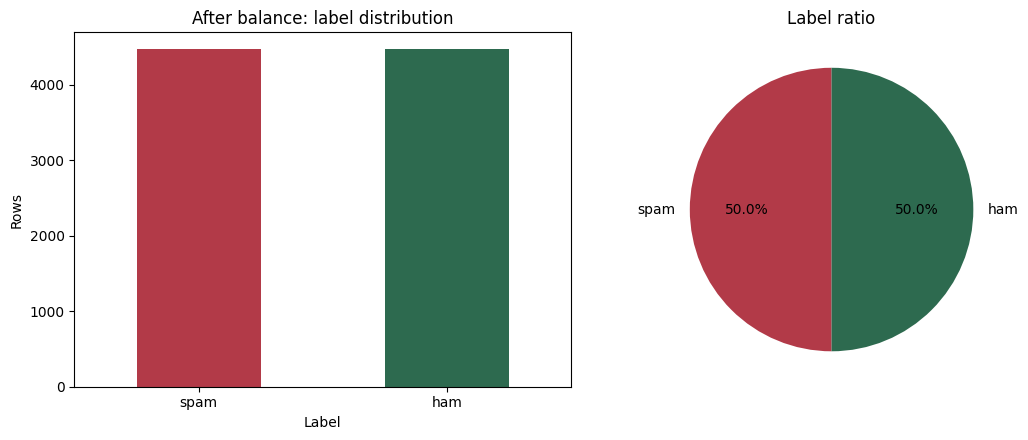

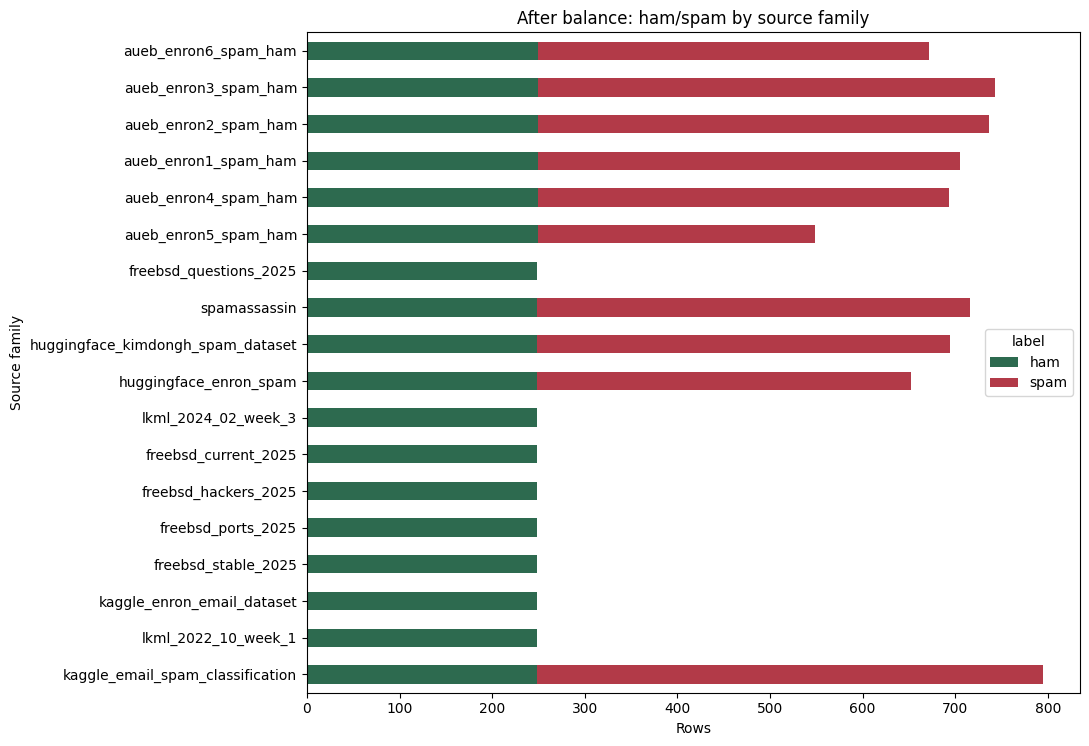

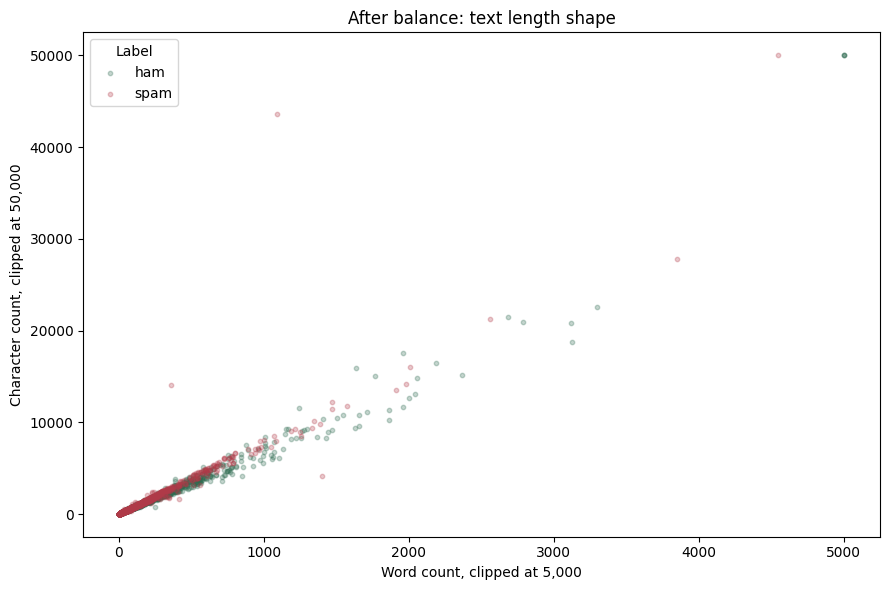

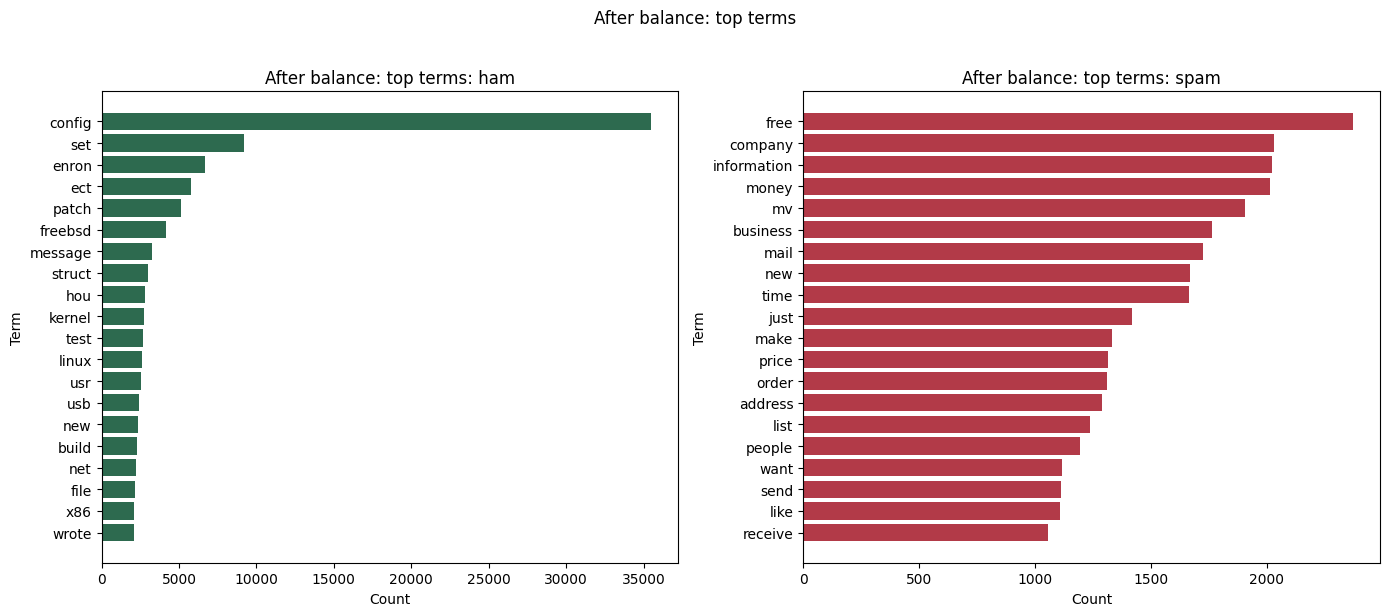

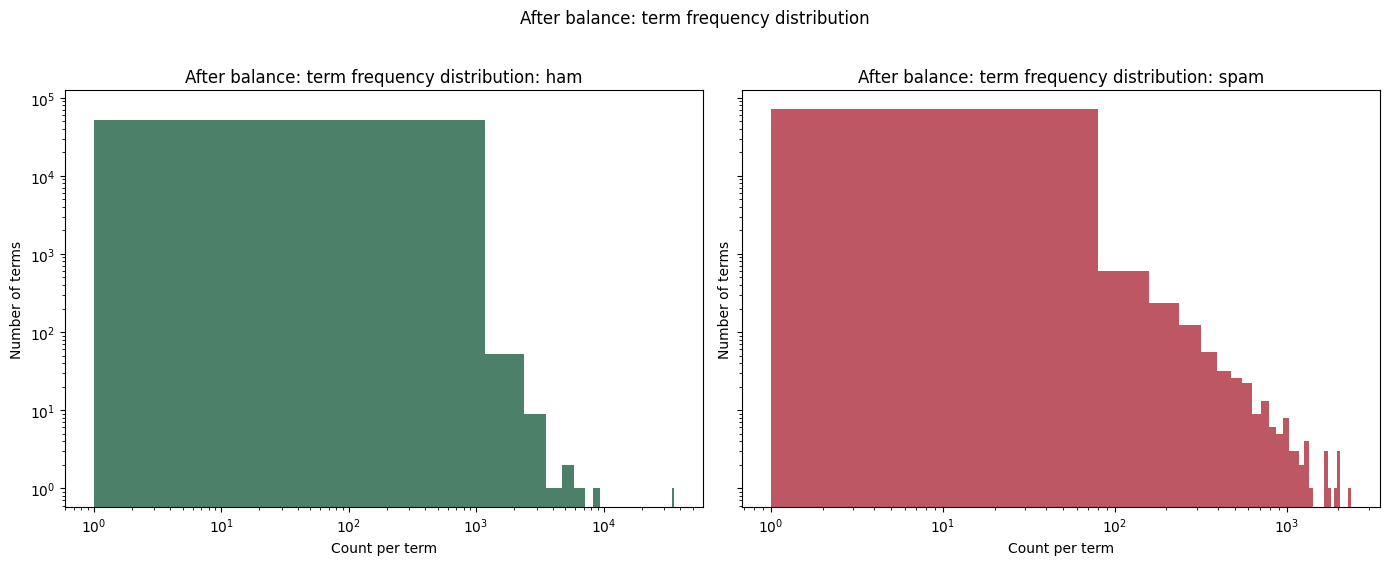

In [220]:
eda = importlib.reload(eda)
eda.plot_eda_overview(data, title_prefix="After balance")

### Step 5 Notes — EDA Reading

## Step 6 — Train/Test Split

Split có stratify theo `source + label` khi đủ dữ liệu, nếu không thì stratify theo label.

In [221]:
split = preprocess.split_training_data(data)
TEXT_COLUMN = split["text_column"]
train_data = split["train_data"]
test_data = split["test_data"]
x_train = split["x_train"]
y_train = split["y_train"]
x_test = split["x_test"]
y_test = split["y_test"]

print(f"Text column: {TEXT_COLUMN}")
print(f"Train rows: {len(train_data):,}")
print(f"Test rows: {len(test_data):,}")
display(preprocess.train_source_crosstab(train_data, top_n=15))

Text column: clean_text
Train rows: 7,152
Test rows: 1,788


label,ham,spam
source_family,,
aueb_enron1_spam_ham,199,365
aueb_enron2_spam_ham,199,391
aueb_enron3_spam_ham,199,395
aueb_enron4_spam_ham,199,355
aueb_enron5_spam_ham,199,240
aueb_enron6_spam_ham,199,339
freebsd_current_2025,199,0
freebsd_hackers_2025,198,0
freebsd_ports_2025,198,0


## Step 7 — Feature Engineering: TF-IDF

TF-IDF không phải là model phân loại. Đây là bước biến email text thành ma trận số để 3 thuật toán bên dưới cùng sử dụng: Naive Bayes, Logistic Regression, và Linear SVM.

In [222]:
tfidf_shape, tfidf_features = model_checker.tfidf_feature_preview(x_train, preview_count=30)

print(f"TF-IDF matrix shape: {tfidf_shape[0]:,} emails x {tfidf_shape[1]:,} features")
print("Example features:")
print(tfidf_features)

TF-IDF matrix shape: 7,152 emails x 176,506 features
Example features:
['000' '000 007f' '00000000000000c0' '000000s' '000e' '000e mails' '000mb'
 '000mb transfers' '000s' '001' '001 0080' '007f' '007f 01bdf6c7' '0080'
 '0080 01bdf6c7' '00am' '00am dec' '00g' '00pm' '00s' '00s 2280k' '00u'
 '00u 00s' '0100056c696e7578' '0100056c696e7578 xxd' '012us' '012us cpu'
 '01am' '01am warner' '01bdf6c7']


## Step 8 — Three Algorithms From Scratch + Sklearn Checker

Tự code 3 thuật toán: Multinomial Naive Bayes, Logistic Regression, Linear SVM. Lớp `SklearnModelChecker` train các model tương ứng bằng sklearn để kiểm tra lại kết quả. Step này dùng sample train có giới hạn để notebook chạy nhanh khi báo cáo.

### Step 8.1 — Build TF-IDF Matrix For Checking

Tạo một sample nhỏ hơn để 3 model from scratch chạy nhanh trong notebook. Cả 3 thuật toán dùng cùng một ma trận TF-IDF để so sánh công bằng.

In [223]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import pandas as pd

MODEL_SAMPLE_ROWS = 3000
CHECK_SAMPLE_ROWS = 1000

model_train_frame = pd.DataFrame(
    {"text": pd.Series(x_train).reset_index(drop=True), "label": pd.Series(y_train).reset_index(drop=True)}
)
model_test_frame = pd.DataFrame(
    {"text": pd.Series(x_test).reset_index(drop=True), "label": pd.Series(y_test).reset_index(drop=True)}
)

if len(model_train_frame) > MODEL_SAMPLE_ROWS:
    model_train_frame, _ = train_test_split(
        model_train_frame,
        train_size=MODEL_SAMPLE_ROWS,
        random_state=42,
        stratify=model_train_frame["label"],
    )
if len(model_test_frame) > CHECK_SAMPLE_ROWS:
    model_test_frame, _ = train_test_split(
        model_test_frame,
        train_size=CHECK_SAMPLE_ROWS,
        random_state=42,
        stratify=model_test_frame["label"],
    )

scratch_vectorizer = model_checker.make_tfidf_vectorizer()
X_train_scratch = scratch_vectorizer.fit_transform(model_train_frame["text"])
X_test_scratch = scratch_vectorizer.transform(model_test_frame["text"])
y_train_scratch = model_train_frame["label"].to_numpy()
y_test_scratch = model_test_frame["label"].to_numpy()

print(f"Scratch/check train matrix: {X_train_scratch.shape}")
print(f"Scratch/check test matrix: {X_test_scratch.shape}")

Scratch/check train matrix: (3000, 63516)
Scratch/check test matrix: (1000, 63516)


### Step 8.2 — Train Three Models From Scratch

Ba class dưới đây là code tự viết trong `model_from_scratch.py`: `ScratchMultinomialNB`, `ScratchLogisticRegression`, và `ScratchLinearSVM`.

,algorithm,class_called_in_notebook,scratch_accuracy
0,Multinomial Naive Bayes,ScratchMultinomialNB,0.974
1,Logistic Regression,ScratchLogisticRegression,0.946
2,Linear SVM,ScratchLinearSVM,0.946


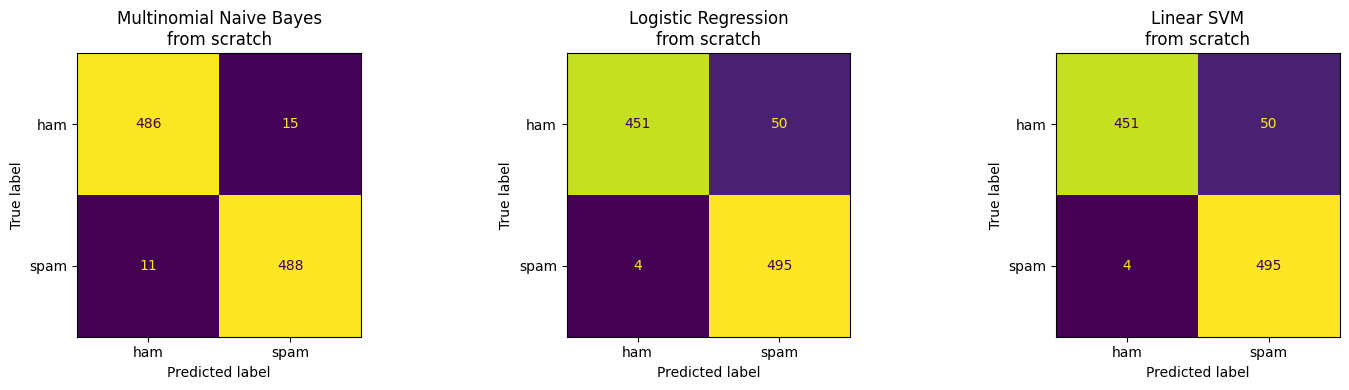

In [224]:
scratch_nb = model_from_scratch.ScratchMultinomialNB(alpha=1.0)
scratch_logistic = model_from_scratch.ScratchLogisticRegression()
scratch_svm = model_from_scratch.ScratchLinearSVM()

scratch_models = {
    "Multinomial Naive Bayes": scratch_nb,
    "Logistic Regression": scratch_logistic,
    "Linear SVM": scratch_svm,
}

scratch_predictions_by_model = {}
for model_name, scratch_model in scratch_models.items():
    scratch_model.fit(X_train_scratch, y_train_scratch)
    scratch_predictions_by_model[model_name] = scratch_model.predict(X_test_scratch)

scratch_summary = pd.DataFrame(
    [
        {
            "algorithm": model_name,
            "class_called_in_notebook": scratch_model.__class__.__name__,
            "scratch_accuracy": accuracy_score(y_test_scratch, scratch_predictions_by_model[model_name]),
        }
        for model_name, scratch_model in scratch_models.items()
    ]
)
display(scratch_summary)

fig, axes = plt.subplots(1, len(scratch_models), figsize=(15, 4))
for axis, (model_name, scratch_predictions) in zip(axes, scratch_predictions_by_model.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test_scratch,
        scratch_predictions,
        labels=["ham", "spam"],
        ax=axis,
        colorbar=False,
    )
    axis.set_title(f"{model_name}\nfrom scratch")
plt.tight_layout()
plt.show()

### Step 8.3 — Double Check With Sklearn: Difference Only

`SklearnModelChecker` train 3 model tương ứng bằng sklearn trên đúng cùng ma trận TF-IDF. Ở đây chỉ báo cáo sai lệch giữa bản from scratch và sklearn: chênh lệch accuracy, tỷ lệ prediction khác nhau, và số mẫu dự đoán khác.

In [225]:
sklearn_checker = model_from_scratch.SklearnModelChecker().fit(X_train_scratch, y_train_scratch)

check_rows = []
for model_name, scratch_predictions in scratch_predictions_by_model.items():
    sklearn_predictions = sklearn_checker.predict(model_name, X_test_scratch)
    scratch_accuracy = accuracy_score(y_test_scratch, scratch_predictions)
    sklearn_accuracy = accuracy_score(y_test_scratch, sklearn_predictions)
    mismatch_count = int((scratch_predictions != sklearn_predictions).sum())

    check_rows.append(
        {
            "algorithm": model_name,
            "scratch_accuracy": scratch_accuracy,
            "sklearn_accuracy": sklearn_accuracy,
            "accuracy_diff_abs": abs(scratch_accuracy - sklearn_accuracy),
            "prediction_disagreement_rate": mismatch_count / len(y_test_scratch),
            "mismatch_count": mismatch_count,
            "checked_rows": len(y_test_scratch),
        }
    )

model_check_differences = pd.DataFrame(check_rows)
display(model_check_differences)

,algorithm,scratch_accuracy,sklearn_accuracy,accuracy_diff_abs,prediction_disagreement_rate,mismatch_count,checked_rows
0,Multinomial Naive Bayes,0.974,0.974,0.000,0.000,0,1000
1,Logistic Regression,0.946,0.973,0.027,0.029,29,1000
2,Linear SVM,0.946,0.975,0.029,0.041,41,1000


## Step 9 — Model Training

In [226]:
model, predictions, baseline_accuracy, model_accuracy = model_checker.train_project_model(x_train, y_train, x_test, y_test)

print(f"Baseline accuracy: {baseline_accuracy:.4f}")
print(f"Naive Bayes accuracy: {model_accuracy:.4f}")

Baseline accuracy: 0.4989
Naive Bayes accuracy: 0.9793


## Step 10 — Evaluate Model

              precision    recall  f1-score   support

         ham       0.98      0.98      0.98       896
        spam       0.98      0.98      0.98       892

    accuracy                           0.98      1788
   macro avg       0.98      0.98      0.98      1788
weighted avg       0.98      0.98      0.98      1788



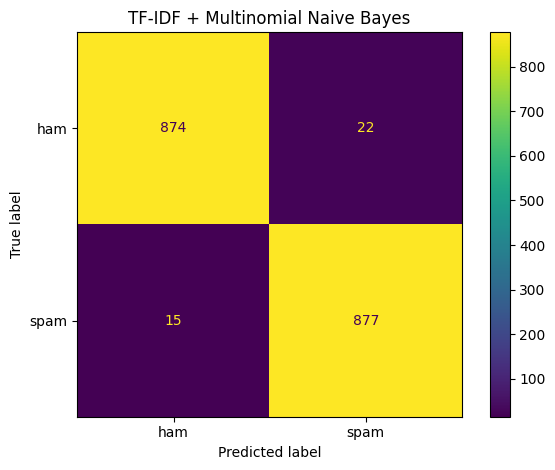

In [227]:
print(eda.classification_report_text(y_test, predictions))

ConfusionMatrixDisplay.from_predictions(y_test, predictions)
plt.title("TF-IDF + Multinomial Naive Bayes")
plt.tight_layout()
plt.show()

### Step 10 Notes — Reading The Metrics

In [228]:
display(eda.top_tokens(model, top_n=15))

label,ham,spam
rank,,
1,ect,free
2,enron,money
3,freebsd,online
4,allen,company
5,hou,mail
6,hou ect,business
7,patch,information
8,ect ect,new
9,phillip,time


In [229]:
display(eda.per_source_scores(test_data, predictions).head(15))

,source_family,rows,accuracy,macro_precision,macro_recall,macro_f1
17,spamassassin,142,0.901408,0.934579,0.857143,0.881667
13,kaggle_email_spam_classification,159,0.943396,0.929245,0.942477,0.935380
0,aueb_enron1_spam_ham,141,0.957447,0.957661,0.949011,0.953083
11,huggingface_enron_spam,131,0.961832,0.955854,0.965309,0.960005
5,aueb_enron6_spam_ham,134,0.992537,0.990196,0.994048,0.992055
3,aueb_enron4_spam_ham,139,0.992806,0.990196,0.994382,0.992225
12,huggingface_kimdongh_spam_dataset,139,0.992806,0.990196,0.994382,0.992225
2,aueb_enron3_spam_ham,149,1.000000,1.000000,1.000000,1.000000
1,aueb_enron2_spam_ham,147,1.000000,1.000000,1.000000,1.000000
4,aueb_enron5_spam_ham,110,1.000000,1.000000,1.000000,1.000000


## Step 11 — Cross-Source Holdout Check

In [230]:
display(eda.cross_source_holdout(data, TEXT_COLUMN, paths["metrics_dir"]).head(15))

,holdout_source,rows,labels,accuracy,macro_f1
0,spamassassin_20021010_hard_ham,66,ham,0.257576,0.409639
1,spamassassin_20021010_easy_ham,101,ham,0.653465,0.790419
2,spamassassin_20030228_easy_ham,71,ham,0.690141,0.816667
3,kaggle_email_spam_classification,795,"ham,spam",0.905660,0.891409
5,huggingface_enron_spam,652,"ham,spam",0.972393,0.970670
6,aueb_enron4_spam_ham,693,"ham,spam",0.974026,0.971640
7,aueb_enron6_spam_ham,672,"ham,spam",0.974702,0.972724
8,aueb_enron1_spam_ham,705,"ham,spam",0.975887,0.973683
9,huggingface_kimdongh_spam_dataset,694,"ham,spam",0.982709,0.981308
11,aueb_enron2_spam_ham,737,"ham,spam",0.985075,0.983369


## Step 12 — Optional Model Comparison

In [231]:
display(model_checker.compare_models(data, TEXT_COLUMN, sample_rows=50_000))

,model,accuracy,macro_precision,macro_recall,macro_f1
2,Linear SVM,0.977069,0.977333,0.977069,0.977066
0,Naive Bayes,0.972595,0.972766,0.972595,0.972593
1,Logistic Regression,0.971477,0.972200,0.971477,0.971466


## Step 13 — Validation-Tuned Balance Strategies

So sánh `Unbalanced`, `Downsample balanced`, và `Weighted balanced` trên cùng một protocol không leakage: threshold được chọn trên validation với ràng buộc `FPR <= 1%`, sau đó mới đánh giá cuối trên test.

Thresholds are selected on validation only; final metrics are evaluated on test only.


split,rows,ham,spam
train_pool,10365,7683,2682
validation,3455,2561,894
test,3455,2561,894


training_strategy,model,score_type,train_rows,ham_train,spam_train,selected_threshold,validation_FPR,validation_TPR,validation_AUC,TN,FP,FN,TP,accuracy,precision,TPR,FPR,FNR,balanced_accuracy,can_reach_99_1_on_validation
Unbalanced,Logistic Regression,probability,10365,7683,2682,0.4822,0.0098,0.8848,0.9963,2539,22,101,793,0.9644,0.9730,0.8870,0.0086,0.1130,0.9392,False
Weighted balanced,Logistic Regression,probability,10365,7683,2682,0.6557,0.0098,0.8893,0.9964,2538,23,94,800,0.9661,0.9721,0.8949,0.0090,0.1051,0.9429,False
Weighted balanced,Naive Bayes,probability,10365,7683,2682,0.8795,0.0098,0.8658,0.9962,2538,23,117,777,0.9595,0.9712,0.8691,0.0090,0.1309,0.9301,False
Downsample balanced,Linear SVM,probability,5364,2682,2682,0.8341,0.0090,0.9418,0.9972,2537,24,59,835,0.9760,0.9721,0.9340,0.0094,0.0660,0.9623,False
Downsample balanced,Naive Bayes,probability,5364,2682,2682,0.7402,0.0098,0.8826,0.9965,2537,24,103,791,0.9632,0.9706,0.8848,0.0094,0.1152,0.9377,False
Weighted balanced,Linear SVM,probability,10365,7683,2682,0.6158,0.0094,0.9530,0.9978,2533,28,45,849,0.9789,0.9681,0.9497,0.0109,0.0503,0.9694,False
Unbalanced,Naive Bayes,probability,10365,7683,2682,0.1286,0.0094,0.9418,0.9969,2533,28,65,829,0.9731,0.9673,0.9273,0.0109,0.0727,0.9582,False
Downsample balanced,Logistic Regression,probability,5364,2682,2682,0.6557,0.0098,0.8960,0.9961,2533,28,93,801,0.9650,0.9662,0.8960,0.0109,0.1040,0.9425,False
Unbalanced,Linear SVM,probability,10365,7683,2682,0.5772,0.0098,0.9553,0.9978,2530,31,40,854,0.9795,0.9650,0.9553,0.0121,0.0447,0.9716,False


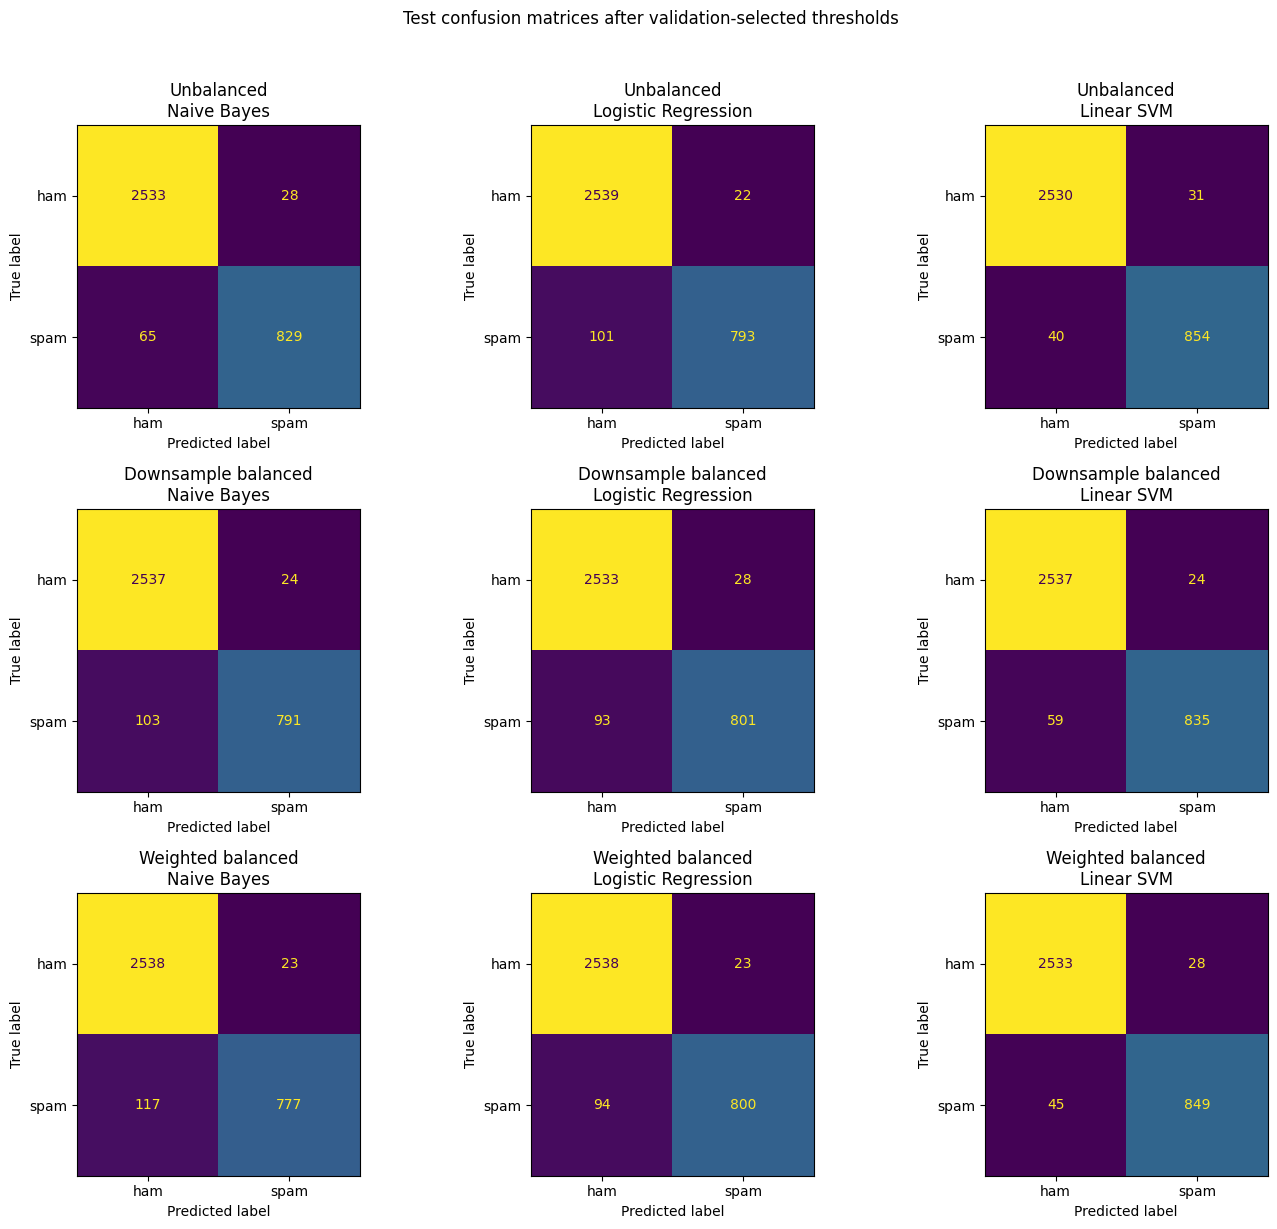

Validation-selected candidate: Unbalanced / Linear SVM -> validation TPR=0.9553, validation FPR=0.0098; test TPR=0.9553, test FPR=0.0121, threshold=0.5772
Diagnostic only - best observed test TPR with test FPR <= 1%: Downsample balanced / Linear SVM -> TPR=0.9340, FPR=0.0094, threshold=0.8341
No validation-tuned model reaches TPR >= 99% and FPR <= 1% on test; the target still requires stronger features/model or more data quality work.


In [ ]:
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

TARGET_FPR = 0.01
TARGET_TPR = 0.99
positive_label = "spam"
negative_label = "ham"
matrix_labels = [negative_label, positive_label]

train_pool, validation_frame, threshold_test_frame = model_checker.split_train_validation_test(
    before_balance_data,
    validation_size=0.2,
    test_size=0.2,
    random_state=42,
)
threshold_specs = model_checker.threshold_experiment_specs(train_pool, TEXT_COLUMN)

split_counts = pd.DataFrame(
    [
        {"split": "train_pool", "rows": len(train_pool), "ham": int((train_pool["label"] == "ham").sum()), "spam": int((train_pool["label"] == "spam").sum())},
        {"split": "validation", "rows": len(validation_frame), "ham": int((validation_frame["label"] == "ham").sum()), "spam": int((validation_frame["label"] == "spam").sum())},
        {"split": "test", "rows": len(threshold_test_frame), "ham": int((threshold_test_frame["label"] == "ham").sum()), "spam": int((threshold_test_frame["label"] == "spam").sum())},
    ]
)
print("Thresholds are selected on validation only; final metrics are evaluated on test only.")
display(split_counts)

threshold_rows = []
validation_roc_curves = []
confusion_matrices = []

for spec in threshold_specs:
    train_frame = spec["train_frame"]
    pipeline = spec["pipeline"]
    pipeline.fit(train_frame[TEXT_COLUMN], train_frame["label"], **spec["fit_params"])

    validation_scores, score_type = model_checker.positive_scores(pipeline, validation_frame[TEXT_COLUMN], positive_label)
    threshold_info = model_checker.threshold_summary(
        validation_frame["label"],
        validation_scores,
        target_fpr=TARGET_FPR,
        target_tpr=TARGET_TPR,
        positive_label=positive_label,
    )
    test_scores, _ = model_checker.positive_scores(pipeline, threshold_test_frame[TEXT_COLUMN], positive_label)
    test_metrics = model_checker.metrics_at_threshold(
        threshold_test_frame["label"],
        test_scores,
        threshold=threshold_info["threshold"],
        positive_label=positive_label,
    )

    assert int((threshold_test_frame["label"] == "ham").sum()) == test_metrics["TN"] + test_metrics["FP"]
    assert int((threshold_test_frame["label"] == "spam").sum()) == test_metrics["FN"] + test_metrics["TP"]

    row = {
        "training_strategy": spec["training_strategy"],
        "model": spec["model"],
        "score_type": score_type,
        "train_rows": len(train_frame),
        "ham_train": int((train_frame["label"] == "ham").sum()),
        "spam_train": int((train_frame["label"] == "spam").sum()),
        "validation_rows": len(validation_frame),
        "test_rows": len(threshold_test_frame),
        "selected_threshold": threshold_info["threshold"],
        "validation_FPR": threshold_info["validation_fpr_at_threshold"],
        "validation_TPR": threshold_info["validation_tpr_at_threshold"],
        "validation_AUC": threshold_info["roc_auc"],
        "can_reach_99_1_on_validation": threshold_info["can_reach_target_on_validation"],
        "closest_threshold": threshold_info["closest_threshold"],
        "closest_validation_FPR": threshold_info["closest_validation_fpr"],
        "closest_validation_TPR": threshold_info["closest_validation_tpr"],
        **test_metrics,
    }
    threshold_rows.append(row)
    validation_roc_curves.append(
        {
            "training_strategy": spec["training_strategy"],
            "model": spec["model"],
            "fpr": threshold_info["roc_fpr"],
            "tpr": threshold_info["roc_tpr"],
            "auc": threshold_info["roc_auc"],
            "selected_validation_FPR": threshold_info["validation_fpr_at_threshold"],
            "selected_validation_TPR": threshold_info["validation_tpr_at_threshold"],
        }
    )
    confusion_matrices.append(
        {
            "training_strategy": spec["training_strategy"],
            "model": spec["model"],
            "matrix": np.array([[test_metrics["TN"], test_metrics["FP"]], [test_metrics["FN"], test_metrics["TP"]]]),
        }
    )

threshold_results = pd.DataFrame(threshold_rows)
round_columns = [
    "selected_threshold", "validation_FPR", "validation_TPR", "validation_AUC",
    "closest_threshold", "closest_validation_FPR", "closest_validation_TPR",
    "accuracy", "precision", "recall", "TPR", "FPR", "FNR", "TNR", "balanced_accuracy",
]
threshold_results[round_columns] = threshold_results[round_columns].round(4)

display_columns = [
    "training_strategy", "model", "score_type", "train_rows", "ham_train", "spam_train",
    "selected_threshold", "validation_FPR", "validation_TPR", "validation_AUC",
    "TN", "FP", "FN", "TP", "accuracy", "precision", "TPR", "FPR", "FNR", "balanced_accuracy",
    "can_reach_99_1_on_validation",
]
display(threshold_results[display_columns].sort_values(["FPR", "TPR"], ascending=[True, False]))

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
for axis, payload in zip(axes.ravel(), confusion_matrices):
    display_obj = ConfusionMatrixDisplay(confusion_matrix=payload["matrix"], display_labels=matrix_labels)
    display_obj.plot(ax=axis, colorbar=False, values_format="d")
    axis.set_title(f'{payload["training_strategy"]}\n{payload["model"]}')

plt.suptitle("Test confusion matrices after validation-selected thresholds", y=1.02)
plt.tight_layout()
plt.show()

validation_candidates = threshold_results[threshold_results["validation_FPR"] <= TARGET_FPR].sort_values("validation_TPR", ascending=False)
validation_choice = validation_candidates.iloc[0]
print(
    f'Validation-selected candidate: {validation_choice["training_strategy"]} / {validation_choice["model"]} '
    f'-> validation TPR={validation_choice["validation_TPR"]:.4f}, validation FPR={validation_choice["validation_FPR"]:.4f}; '
    f'test TPR={validation_choice["TPR"]:.4f}, test FPR={validation_choice["FPR"]:.4f}, threshold={validation_choice["selected_threshold"]:.4f}'
)

test_diagnostic = threshold_results[threshold_results["FPR"] <= TARGET_FPR].sort_values("TPR", ascending=False)
if not test_diagnostic.empty:
    best_test = test_diagnostic.iloc[0]
    print(
        f'Diagnostic only - best observed test TPR with test FPR <= 1%: {best_test["training_strategy"]} / {best_test["model"]} '
        f'-> TPR={best_test["TPR"]:.4f}, FPR={best_test["FPR"]:.4f}, threshold={best_test["selected_threshold"]:.4f}'
    )
else:
    best_test = threshold_results.sort_values(["FPR", "TPR"], ascending=[True, False]).iloc[0]
    print(
        f'Diagnostic only - no model keeps test FPR <= 1%. Lowest-FPR option: {best_test["training_strategy"]} / {best_test["model"]} '
        f'-> TPR={best_test["TPR"]:.4f}, FPR={best_test["FPR"]:.4f}'
    )

if ((threshold_results["TPR"] >= TARGET_TPR) & (threshold_results["FPR"] <= TARGET_FPR)).any():
    print("At least one validation-tuned model reaches TPR >= 99% and FPR <= 1% on test.")
else:
    print("No validation-tuned model reaches TPR >= 99% and FPR <= 1% on test; the target still requires stronger features/model or more data quality work.")

## Step 14 — Low-FPR ROC View

Zoom vào vùng FPR thấp để xem model nào giữ được false positive thấp nhất trong khi tăng TPR.

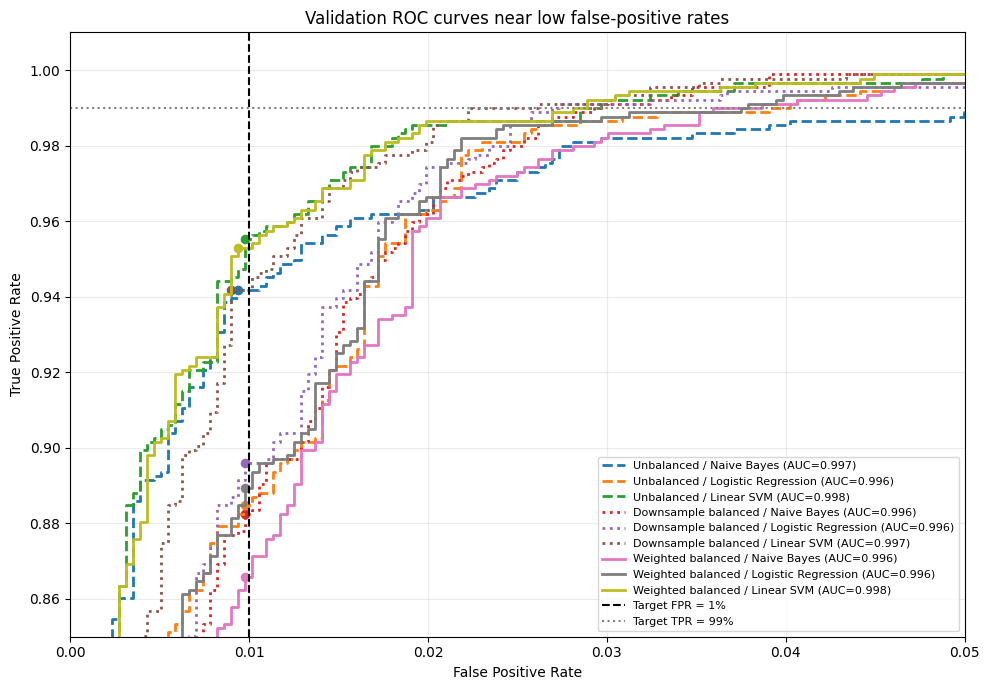

FPR                                              TPR                                balanced_accuracy                                        precision                             training_strategy   Downsample balanced Unbalanced Weighted balanced Downsample balanced Unbalanced Weighted balanced Downsample balanced Unbalanced Weighted balanced Downsample balanced Unbalanced Weighted balancedmodel                                                                                                                                                                                                                  Linear SVM                       0.0094     0.0121            0.0109              0.9340     0.9553            0.9497              0.9623     0.9716            0.9694              0.9721     0.9650            0.9681Logistic Regression              0.0109     0.0086            0.0090              0.8960     0.8870            0.8949              0.9425     0.9392            0.9429              0.9662     0.9730            0.9721Naive Bayes                      0.0094     0.0109            0.0090              0.8848     0.9273            0.8691              0.9377     0.9582            0.9301              0.9706     0.9673            0.9712

In [ ]:
plt.figure(figsize=(10, 7))
line_styles = {"Unbalanced": "--", "Downsample balanced": ":", "Weighted balanced": "-"}
for curve in validation_roc_curves:
    plt.plot(
        curve["fpr"],
        curve["tpr"],
        linestyle=line_styles[curve["training_strategy"]],
        linewidth=2,
        label=f'{curve["training_strategy"]} / {curve["model"]} (AUC={curve["auc"]:.3f})',
    )
    plt.scatter(curve["selected_validation_FPR"], curve["selected_validation_TPR"], s=35)

plt.axvline(TARGET_FPR, color="black", linestyle="--", linewidth=1.5, label="Target FPR = 1%")
plt.axhline(TARGET_TPR, color="gray", linestyle=":", linewidth=1.5, label="Target TPR = 99%")
plt.xlim(0, 0.05)
plt.ylim(0.85, 1.01)
plt.title("Validation ROC curves near low false-positive rates")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(alpha=0.25)
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

weighted_vs_downsample = threshold_results.pivot_table(
    index="model",
    columns="training_strategy",
    values=["TPR", "FPR", "precision", "balanced_accuracy"],
    aggfunc="first",
)
display(weighted_vs_downsample)

## Step 15 — Save And Reuse The Model

In [233]:
saved_model_path = model_checker.save_model(model, paths["model"])
print(f"Saved model to {saved_model_path.relative_to(PROJECT_ROOT)}")

Saved model to models/spam_nb.joblib


In [234]:
display(model_checker.predict_new_emails(paths["model"]))

,email_text,clean_text,prediction,confidence
0,Win cash now! Click the prize link and claim y...,win cash prize link claim bonus today,spam,0.9081
1,"Hi team, attached are the meeting notes and ne...",hi team attached meeting notes steps today's p...,ham,0.8829


## Step 16 — Project Reports

In [235]:
display(crawl.report_status(paths["metrics_dir"], PROJECT_ROOT))

print("\nSaved classification report:\n")
print(crawl.read_classification_report(paths["metrics_dir"]))

,report,status
0,data/processed/metrics/preprocessing_balance_r...,exists
1,data/processed/metrics/classification_report.txt,exists
2,data/processed/metrics/model_summary.md,exists
3,data/processed/metrics/per_source_classificati...,exists
4,data/processed/metrics/cross_source_holdout_re...,exists



Saved classification report:

              precision    recall  f1-score   support

         ham       0.98      0.98      0.98       896
        spam       0.98      0.98      0.98       892

    accuracy                           0.98      1788
   macro avg       0.98      0.98      0.98      1788
weighted avg       0.98      0.98      0.98      1788

